In [10]:
import numpy as np
from sklearn.datasets import make_regression

np.random.seed(0) # for reproducibility
X, y, true_coefs = make_regression(
n_samples=100,
n_features=10,
n_informative=3,
noise=10.0,
coef=True,
random_state=42

)

In [11]:
from sklearn.model_selection import train_test_split
# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
# Ordinary Least Squares (no penalty)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
print("OLS Coefficients:", np.round(lr.coef_, 2))
print("OLS Intercept:", np.round(lr.intercept_, 2))
print("OLS Test MSE:", np.round(mse_lr, 2))


OLS Coefficients: [16.19 -0.78  0.9  62.19  2.05 -0.56 -0.17 10.06  0.81 -0.6 ]
OLS Intercept: 1.85
OLS Test MSE: 128.73


In [23]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV

# Range of alphas (regularization strength) on log scale
alphas = np.logspace(-3, 3, 40)

ridge_coefs, lasso_coefs, enet_coefs = [], [], []
mse_ridge_test, mse_lasso_test, mse_enet_test = [], [], []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)
    mse_ridge_test.append(mean_squared_error(y_test, ridge.predict(X_test)))

    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_coefs.append(lasso.coef_)
    mse_lasso_test.append(mean_squared_error(y_test, lasso.predict(X_test)))

    # Elastic Net
    enet = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000)
    enet.fit(X_train, y_train)
    enet_coefs.append(enet.coef_)
    mse_enet_test.append(mean_squared_error(y_test, enet.predict(X_test)))

# Best alpha by TEST MSE (from your loop)
best_alpha_ridge = alphas[np.argmin(mse_ridge_test)]
best_alpha_lasso = alphas[np.argmin(mse_lasso_test)]
best_alpha_enet  = alphas[np.argmin(mse_enet_test)]

print(f"Best Ridge alpha by test MSE: {best_alpha_ridge}")
print(f"Best Lasso alpha by test MSE: {best_alpha_lasso}")
print(f"Best ElasticNet alpha by test MSE: {best_alpha_enet}")

# Cross-validated alpha check
ridge_cv = RidgeCV(alphas=alphas, cv=5).fit(X_train, y_train)
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42).fit(X_train, y_train)
enet_cv = ElasticNetCV(alphas=alphas, l1_ratio=[0.5], cv=5, max_iter=10000, random_state=42).fit(X_train, y_train)

print(f"RidgeCV alpha: {ridge_cv.alpha_}")
print(f"LassoCV alpha: {lasso_cv.alpha_}")
print(f"ElasticNetCV alpha: {enet_cv.alpha_}")

Best Ridge alpha by test MSE: 0.001
Best Lasso alpha by test MSE: 0.14251026703029993
Best ElasticNet alpha by test MSE: 0.001
RidgeCV alpha: 0.001
LassoCV alpha: 0.8376776400682924
ElasticNetCV alpha: 0.001


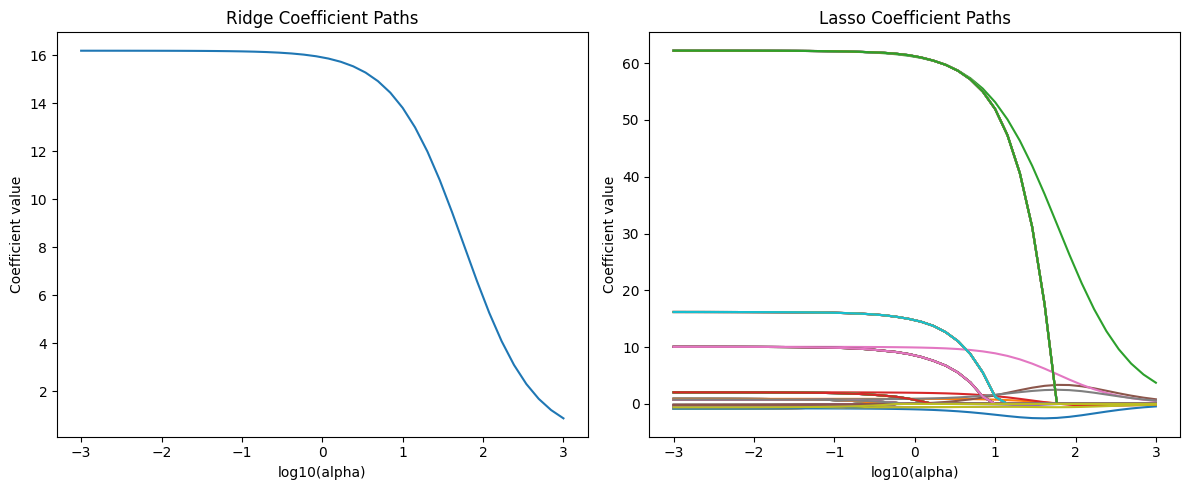

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
# Ridge coefficients vs log(alpha)
plt.subplot(1, 2, 1)
for i in range(len(ridge_coefs[0])):
    plt.plot(np.log10(alphas), [coef[i] for coef in ridge_coefs])
    plt.xlabel('log10(alpha)')
    plt.ylabel('Coefficient value')
    plt.title('Ridge Coefficient Paths')
    # Lasso coefficients vs log(alpha)
    plt.subplot(1, 2, 2)
    for i in range(len(lasso_coefs[0])):
        plt.plot(np.log10(alphas), [coef[i] for coef in lasso_coefs])
        plt.xlabel('log10(alpha)')
        plt.ylabel('Coefficient value')
        plt.title('Lasso Coefficient Paths')
        plt.tight_layout()
        plt.savefig('coef_paths.png')

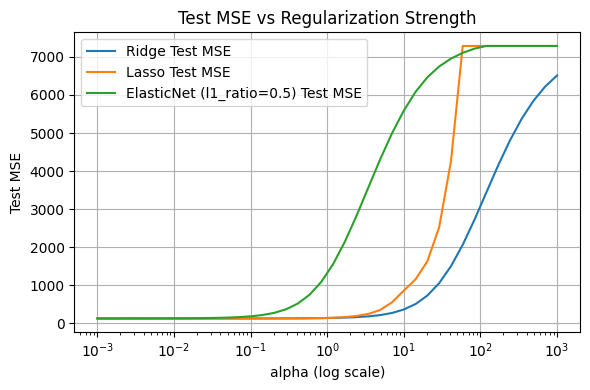

In [16]:
plt.figure(figsize=(6,4))
plt.semilogx(alphas, mse_ridge_test, label='Ridge Test MSE')
plt.semilogx(alphas, mse_lasso_test, label='Lasso Test MSE')
plt.semilogx(alphas, mse_enet_test, label='ElasticNet (l1_ratio=0.5) Test MSE')
plt.xlabel('alpha (log scale)')
plt.ylabel('Test MSE')
plt.title('Test MSE vs Regularization Strength')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('mse_vs_alpha.png')


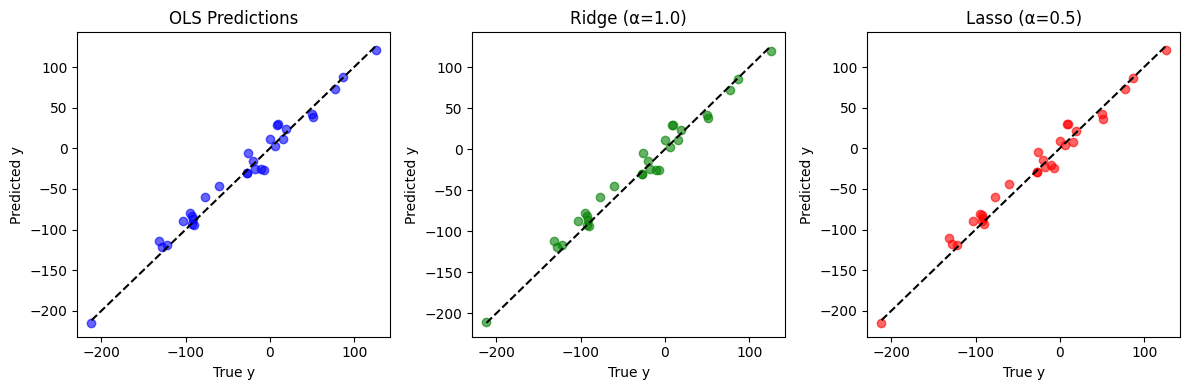

In [17]:
# Choose alpha for plotting predictions
alpha_ridge = 1.0
alpha_lasso = 0.5
# Re-fit with chosen alpha
ridge_model = Ridge(alpha=alpha_ridge); ridge_model.fit(X_train, y_train)
lasso_model = Lasso(alpha=alpha_lasso, max_iter=10000);
lasso_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)
plt.figure(figsize=(12,4))
# OLS
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('True y'); plt.ylabel('Predicted y')
plt.title('OLS Predictions')
# Ridge
plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_ridge, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('True y'); plt.ylabel('Predicted y')
plt.title(f'Ridge (α={alpha_ridge})')
# Lasso
plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_lasso, color='red', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('True y'); plt.ylabel('Predicted y')
plt.title(f'Lasso (α={alpha_lasso})')
plt.tight_layout()
plt.savefig('pred_vs_true.png')


In [18]:
from sklearn.linear_model import RidgeCV, LassoCV

# 1. Provide a list of alphas to test
alphas_to_test = np.logspace(-3, 3, 40)

# 2. Tell RidgeCV to test them all using 5-fold cross-validation
ridge_cv = RidgeCV(alphas=alphas_to_test, cv=5)
ridge_cv.fit(X_train, y_train)

# 3. It automatically stores the absolute best alpha it found!
print(f"The mathematically ideal Ridge alpha is: {ridge_cv.alpha_}")

# 4. Now use it to predict
best_ridge_predictions = ridge_cv.predict(X_test)

The mathematically ideal Ridge alpha is: 0.001
